In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
from primordialpy.pbhabundance import PBHAbundance
from primordialpy.pbhconstraints import PBHConstraints
from primordialpy.inducedGW import InducedGW

import matplotlib.pyplot as plt

In [2]:
V = 'V_0*phi**2/(phi**2 + m**2)*(1 + A*exp(-0.5*(phi - phi_0)**2/sigma**2) )'
parameters = {'V_0' : 0.79e-10, 'm' : 0.5, 'A' : 1.17035e-3, 'phi_0' : 2.188, 'sigma': 1.59e-2}
potential = PotentialFunction.function(V, param_values=parameters) 

#Creando instancia de la clase Background. Resuelve automáticamente el sistema dada la condición inicial del inflatón
background = Background(potential, phi0 = 3.2) 
background.solver()

In [ ]:
#Extrayendo datos de la clase background
N, phi, dphidN, H, a, aH, eps_H, eta_H = background.data().values()
background.save_background(path='./Data')
Nend = N[-1]
Nend

Saved to ./Data/background.dat


np.float64(71.54715471547155)

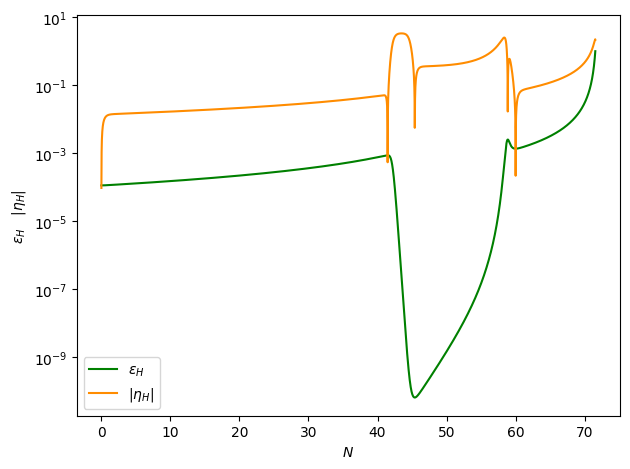

In [4]:
plt.plot(N, eps_H, label = r'$\epsilon_H$', color = 'green' )
plt.plot(N, abs(eta_H), label = r'$|\eta_H |$', color = 'darkorange')

plt.yscale('log')
plt.xlabel(r'$N$')
plt.ylabel(r'$\epsilon_H\quad |\eta_H|$')
plt.legend(loc = 3)
#plt.title('Slow-roll parameters')
plt.tight_layout()


In [5]:
pert = Perturbations(potential, background, scale= 'PBH', N_CMB = 60)
sol_pivot = pert.power_spectra_pivot()

Curvature power spectrum at pivot scale is 2.129835632651798e-09
Tensor to scalar ratio at pivot scale is 0.0024383964294820938


In [21]:
PS = pert.power_spectrum()
pert.save_power_spectra(path ='./Data')

Computing P(k): 100%|██████████| 1000/1000 [00:21<00:00, 45.58it/s]


$Ps_peak = 2.8067\times 10^{-02}$
$k_peak = 4.6358\times 10^{+12}\,\mathrm{Mpc}^-1$
Saved to ./Data/power_spectra.dat


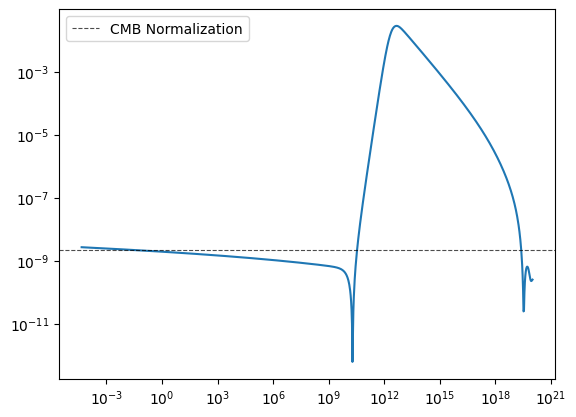

In [22]:
plt.loglog(pert.k_modes, PS[0])
plt.axhline(y = 2.1e-9, label = 'CMB Normalization', alpha = 0.7, color = 'k', linestyle = 'dashed', linewidth = 0.8)
plt.legend()

In [23]:
print(pert.spectral_tilts)

{'n_s': 0.9659442834825479, 'n_t': -0.0003149831091307941}


In [25]:
pbh = PBHAbundance(perturbations=pert, delta_c=0.414, gamma=0.2, gstar=106.75)
mPBH, fPBH = pbh.fPBH()
pbh.save_pbh(path='./Data')


fPBH_peak = 0.03773778089597294
MPBH_peak = 1.635411774084081e-13 M⊙
Saved to ./Data/pbh_abundance.dat


In [28]:
gw = InducedGW(perturbations=pert)
f, omega = gw.compute(n_int= 500)
gw.save_gw(path= './Data')

Computing SIGW for 1000 modes...
Omega_GW_peak = 7.974142945234953e-09
f_peak = 0.008017981413468211 Hz
Saved to ./Data/gw_data.dat


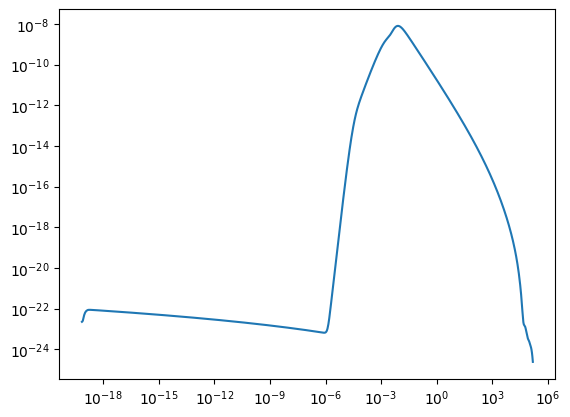

In [29]:
plt.loglog(f, omega)
